In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Fashion_Retail_Sales.csv')
df.head()

,Customer Reference ID,Item Purchased,Purchase Amount (USD),Date Purchase,Review Rating,Payment Method
0,4115,Tunic,2456.0,11-07-2023,2.0,Credit Card
1,4019,Tank Top,2102.0,23-03-2023,4.1,Cash
2,4097,Leggings,3126.0,15-03-2023,3.2,Cash
3,3997,Wallet,3003.0,27-11-2022,4.7,Cash
4,4080,Onesie,2914.0,11-12-2022,4.5,Credit Card


In [ ]:
df.tail()

,Customer Reference ID,Item Purchased,Purchase Amount (USD),Date Purchase,Review Rating,Payment Method
2482,4040,Tank Top,113.0,20-01-2023,1.2,Credit Card
2483,4118,Shorts,37.0,09-07-2023,2.7,Cash
2484,4056,Slippers,176.0,16-03-2023,2.5,Cash
2485,4042,Sandals,128.0,01-01-2023,1.8,Cash
2486,4001,Backpack,115.0,22-03-2023,1.4,Cash


In [ ]:
# Data Understanding

df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2487 entries, 0 to 2486
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Reference ID  2487 non-null   int64  
 1   Item Purchased         2487 non-null   object 
 2   Purchase Amount (USD)  2487 non-null   float64
 3   Date Purchase          2487 non-null   object 
 4   Review Rating          2487 non-null   float64
 5   Payment Method         2487 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 116.7+ KB


,Customer Reference ID,Purchase Amount (USD),Review Rating
count,2487.000000,2487.000000,2487.000000
mean,4040.224769,149.609972,2.986248
std,48.364412,389.263631,1.150691
min,3957.000000,10.000000,1.000000
25%,3998.000000,57.000000,2.000000
50%,4042.000000,110.000000,3.000000
75%,4082.000000,154.000000,4.000000
max,4122.000000,4932.000000,5.000000


In [ ]:
df["Item Purchased"].value_counts().head(10)

,count
Item Purchased,
Shorts,69
Belt,65
Skirt,63
Camisole,60
Tank Top,60
Pants,59
Cardigan,57
Hoodie,57
Wallet,56


In [ ]:
# Data Cleaning
df = df.drop_duplicates()

In [ ]:
df.isnull().sum()

df = df.dropna()   # OR can use fillna()

In [ ]:
df = df.drop(columns=["Unnecessary_Column"], errors='ignore')

In [ ]:
df.rename(columns={"Purchase Amount (USD)":"Purchase Amount"}, inplace=True)

In [ ]:
df.head()

,Customer Reference ID,Item Purchased,Purchase Amount,Date Purchase,Review Rating,Payment Method
0,4115,Tunic,2456.0,11-07-2023,2.0,Credit Card
1,4019,Tank Top,2102.0,23-03-2023,4.1,Cash
2,4097,Leggings,3126.0,15-03-2023,3.2,Cash
3,3997,Wallet,3003.0,27-11-2022,4.7,Cash
4,4080,Onesie,2914.0,11-12-2022,4.5,Credit Card


In [ ]:
# Data Preprocessing

df["Purchase Amount"] = pd.to_numeric(df["Purchase Amount"], errors='coerce')

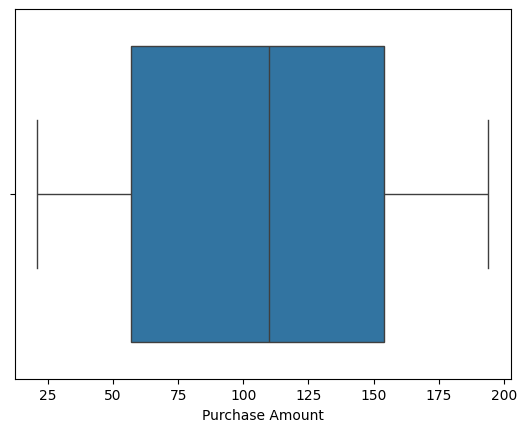

In [ ]:
sns.boxplot(x=df["Purchase Amount"])
upper_limit = df["Purchase Amount"].quantile(0.95)
lower_limit = df["Purchase Amount"].quantile(0.05)

df["Purchase Amount"] = df["Purchase Amount"].clip(lower_limit, upper_limit)

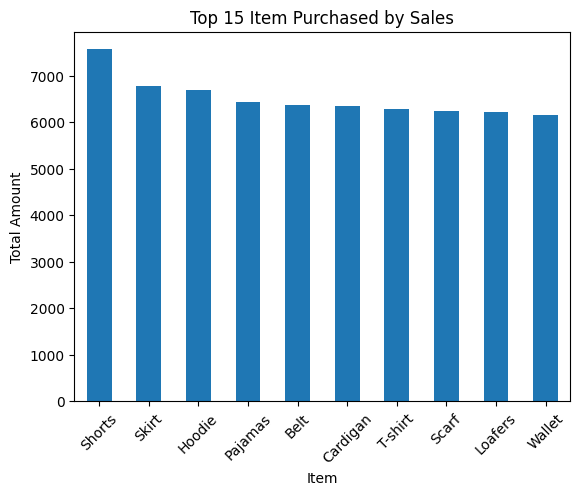

In [ ]:
# Exploratory Data Analysis (EDA)

top_categories = df.groupby("Item Purchased")["Purchase Amount"].sum().nlargest(10)
top_categories.plot(kind='bar')
plt.title("Top 15 Item Purchased by Sales")
plt.xlabel("Item")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.show()

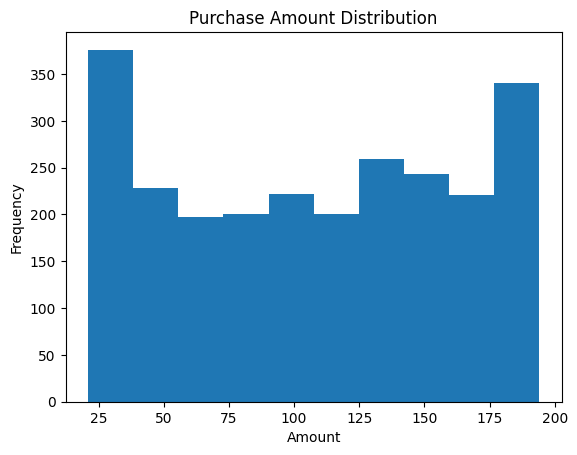

In [ ]:
plt.hist(df["Purchase Amount"])
plt.title("Purchase Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

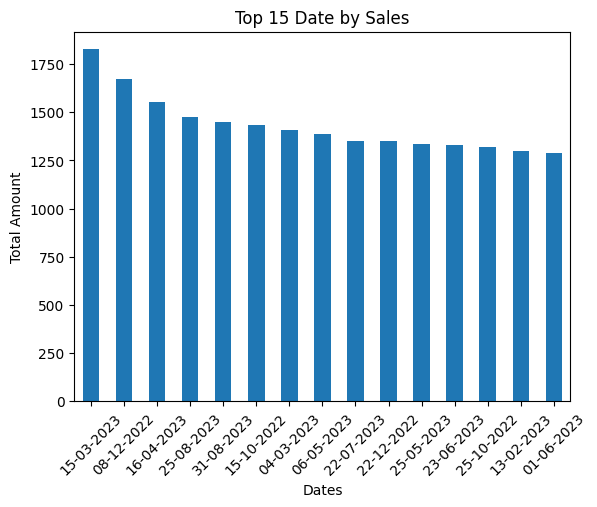

In [ ]:
top_Dates = df.groupby("Date Purchase")["Purchase Amount"].sum().sort_values(ascending=False).head(15)

top_Dates.plot(kind='bar')
plt.title("Top 15 Date by Sales")
plt.xlabel("Dates")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.show()

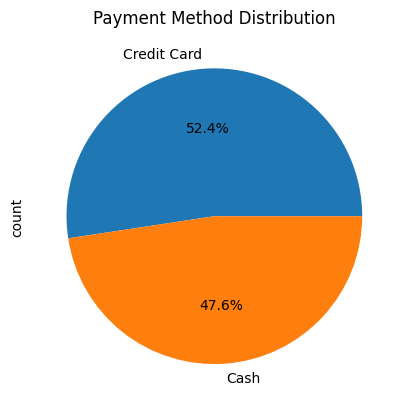

In [ ]:
df["Payment Method"].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.show()

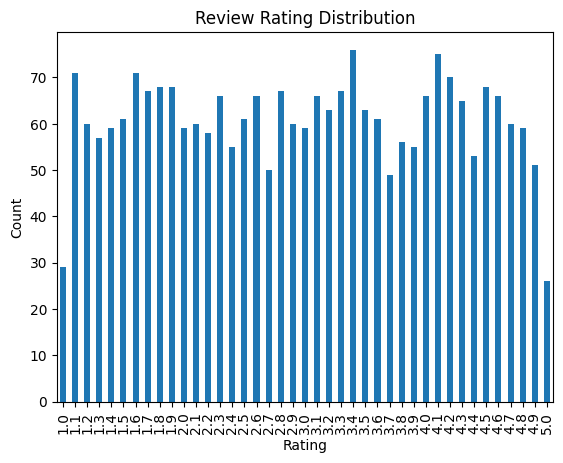

In [ ]:
df["Review Rating"].value_counts().sort_index().plot(kind='bar')
plt.title("Review Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

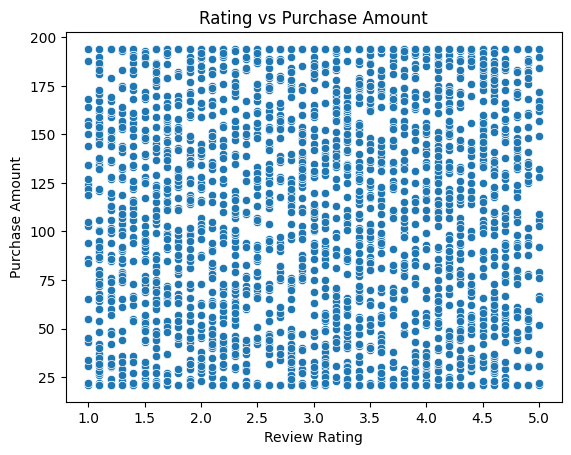

In [ ]:
sns.scatterplot(x="Review Rating", y="Purchase Amount", data=df)
plt.title("Rating vs Purchase Amount")
plt.show()

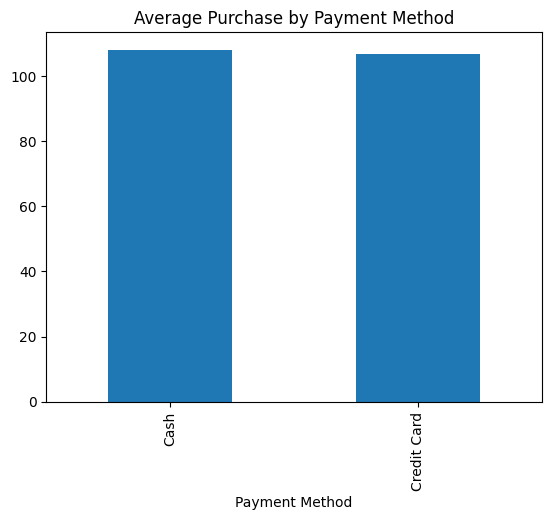

In [ ]:
df.groupby("Payment Method")["Purchase Amount"].mean().plot(kind='bar')
plt.title("Average Purchase by Payment Method")
plt.show()

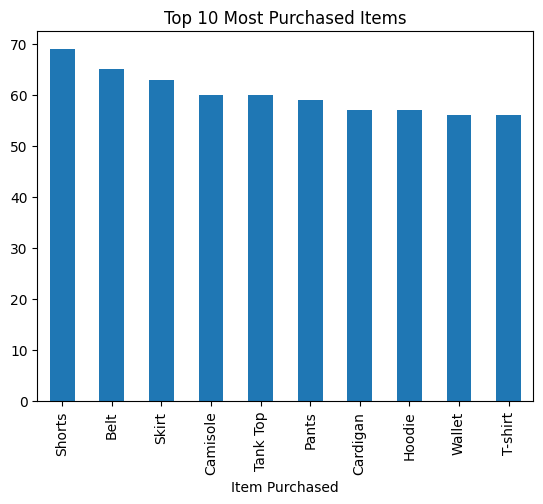

In [ ]:
df["Item Purchased"].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Most Purchased Items")
plt.show()

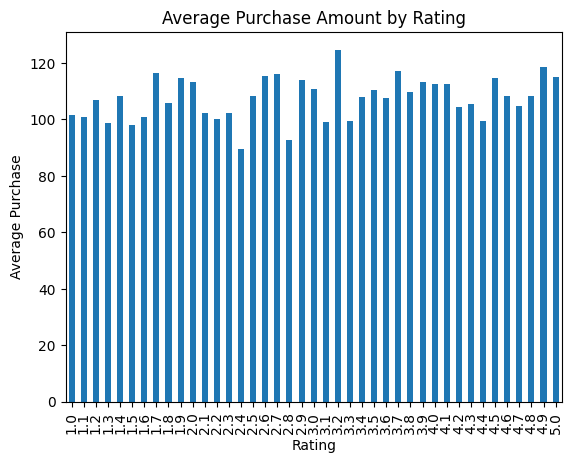

In [ ]:
df.groupby("Review Rating")["Purchase Amount"].mean().plot(kind='bar')
plt.title("Average Purchase Amount by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Purchase")
plt.show()

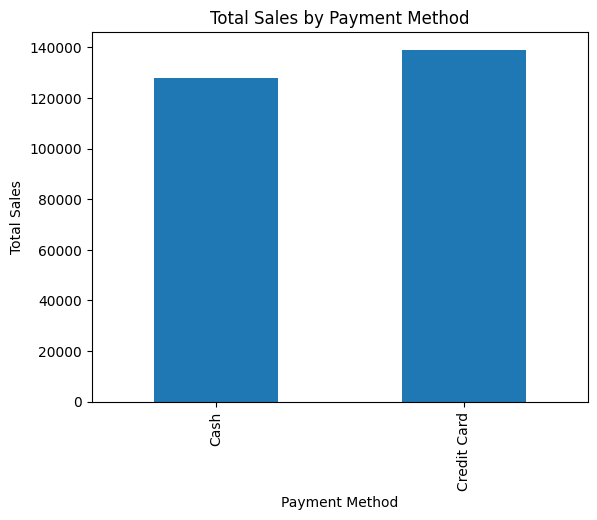

In [ ]:
df.groupby("Payment Method")["Purchase Amount"].sum().plot(kind='bar')
plt.title("Total Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")
plt.show()

In [ ]:
df.to_csv('/content/drive/MyDrive/fashion_retail_cleaned.csv', index=False)